# Step 2 — Light Curve Cleaning and Preprocessing

## Exoplanet Transit Detection Pipeline

### Objective

Raw light curves from space telescopes contain non-astrophysical noise, instrumental drifts, stellar variability, and missing data points.

In this notebook, I will clean and preprocess the raw light curve from **Step 1** to prepare it for analysis and transit searches.

### Key Preprocessing Steps:
1. **Remove Missing Values ($\text{NaN}$s):** Handle missing sensor measurements.
2. **Normalise Flux:** Convert raw photon counts ($\text{e}^-/\text{s}$) into relative flux centered around 1.0.
3. **Detrend / Flatten Signal:** Remove low-frequency instrumental and stellar noise using a Savitzky-Golay filter.
4. **Remove Outliers:** Clip single-cadence upward and downward spikes (e.g., cosmic rays) via $\sigma$-clipping.

---

In [11]:
import lightkurve as lk
import matplotlib.pyplot as plt
import numpy as np

# Load target light curve (Kepler-10, Quarter 2)
search_result = lk.search_lightcurve("Kepler-10", mission="Kepler", quarter=2)
lc_raw = search_result.download()

print("Loaded Raw Light Curve:")
print(f"Number of cadence points: {len(lc_raw)}")

Loaded Raw Light Curve:
Number of cadence points: 43363


/Users/soSophiephiemainprize/miniforge3/lib/python3.12/site-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 3 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


### 1. Remove Missing Data ($\text{NaN}$s)

**Why:** Telescope communications drops or detector issues lead to missing or undefined measurements ($\text{NaN}$). Statistical operations and algorithms fail when encountering $\text{NaN}$ values.

In [12]:
# Remove NaN values from flux and time arrays
lc_nans_removed = lc_raw.remove_nans()

nans_count = len(lc_raw) - len(lc_nans_removed)
print(f"Removed {nans_count} NaN values.")
print(f"Remaining data points: {len(lc_nans_removed)}")

Removed 2 NaN values.
Remaining data points: 43361


### 2. — Normalise Flux

**Why:** Raw light curves are measured in absolute photon counts ($\text{e}^-/\text{s}$). Transit depths are defined as relative brightness drops ($\Delta F / F$). Normalising scales the median baseline of the light curve to $1.0$.

In [13]:
# Normalise the flux relative to its baseline median
lc_norm = lc_nans_removed.normalize()

print(f"Raw median flux: {np.nanmedian(lc_nans_removed.flux):.2f}")
print(f"Normalised median flux: {np.nanmedian(lc_norm.flux):.2f}")

# Visualise Normalised Data
lc_norm.plot(title="Step 2.2: Normalised Light Curve", color="black", alpha=0.7);

Raw median flux: 556935.81 electron / s
Normalised median flux: 1.00


### 3. — Remove Low-Frequency Instrumental and Stellar Noise

**Why:** Stellar activity (starspots, rotation) and spacecraft thermal drift create broad, continuous waves across days or weeks. Removing this long-term trend isolates short, shallow dips caused by exoplanet transits.

**Method:** I fitted a running Savitzky-Golay polynomial smoothing filter across a sliding window (`window_length`).
- `window_length`: Must be wide enough (e.g., 101 cadences $\approx$ ~2 days) so it captures stellar trends without accidentally smoothing out a short transit dip ($\approx$ 2–6 hours).

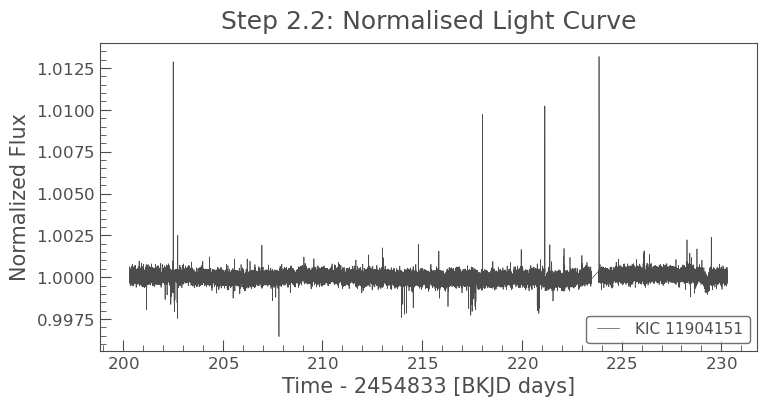

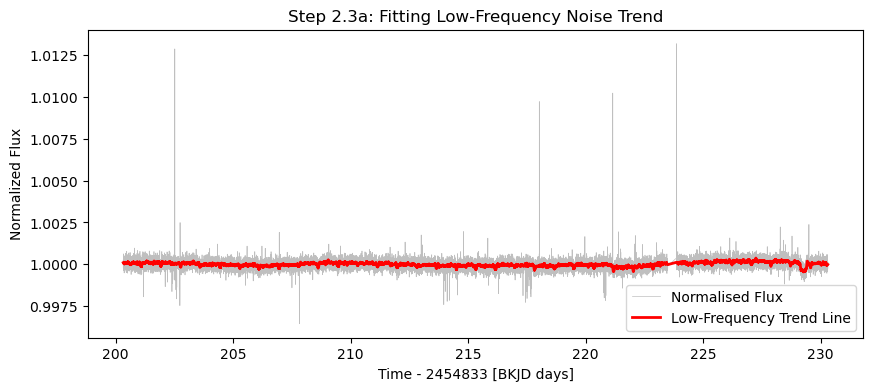

In [14]:
# Apply Savitzky-Golay flattening filter and extract both the trend and flattened LC
lc_flat, trend = lc_norm.flatten(window_length=101, return_trend=True)

# Plot trend line over normalised light curve
fig, ax = plt.subplots(figsize=(10, 4))
lc_norm.plot(ax=ax, color='grey', alpha=0.5, label='Normalised Flux')
trend.plot(ax=ax, color='red', linewidth=2, label='Low-Frequency Trend Line')
plt.title("Step 2.3a: Fitting Low-Frequency Noise Trend")
plt.legend()
plt.show()

# Plot flattened light curve
lc_flat.plot(color='navy', alpha=0.6, title="Step 2.3b: Flattened Signal (Trend Divided Out)");

### 4. — Remove Outliers ($\sigma$-Clipping)

**Why:** High-energy particles (cosmic rays) striking the detector create sharp upward flux spikes. Detector glitches can create downward single-point anomalies. 

**Method:** I have used asymmetric standard deviation ($\sigma$) clipping:
- `sigma_upper=5`: Strict filter for cosmic ray upward spikes ($> 5\sigma$).
- `sigma_lower=3`: Conservative filter for downward points ($> 3\sigma$) to avoid removing actual transit dips.

In [16]:
# Remove cosmic rays and extreme single-point anomalies
lc_cleaned = lc_flat.remove_outliers(sigma_upper=5, sigma_lower=3)

outliers_count = len(lc_flat) - len(lc_cleaned)
print(f"Removed {outliers_count} outlier data points.")
print(f"Final dataset length: {len(lc_cleaned)}")

Removed 154 outlier data points.
Final dataset length: 43207


### 5. — Final Preprocessing Pipeline Visualisation

Comparing the original raw signal against the final cleaned, detrended, and outlier-free light curve.

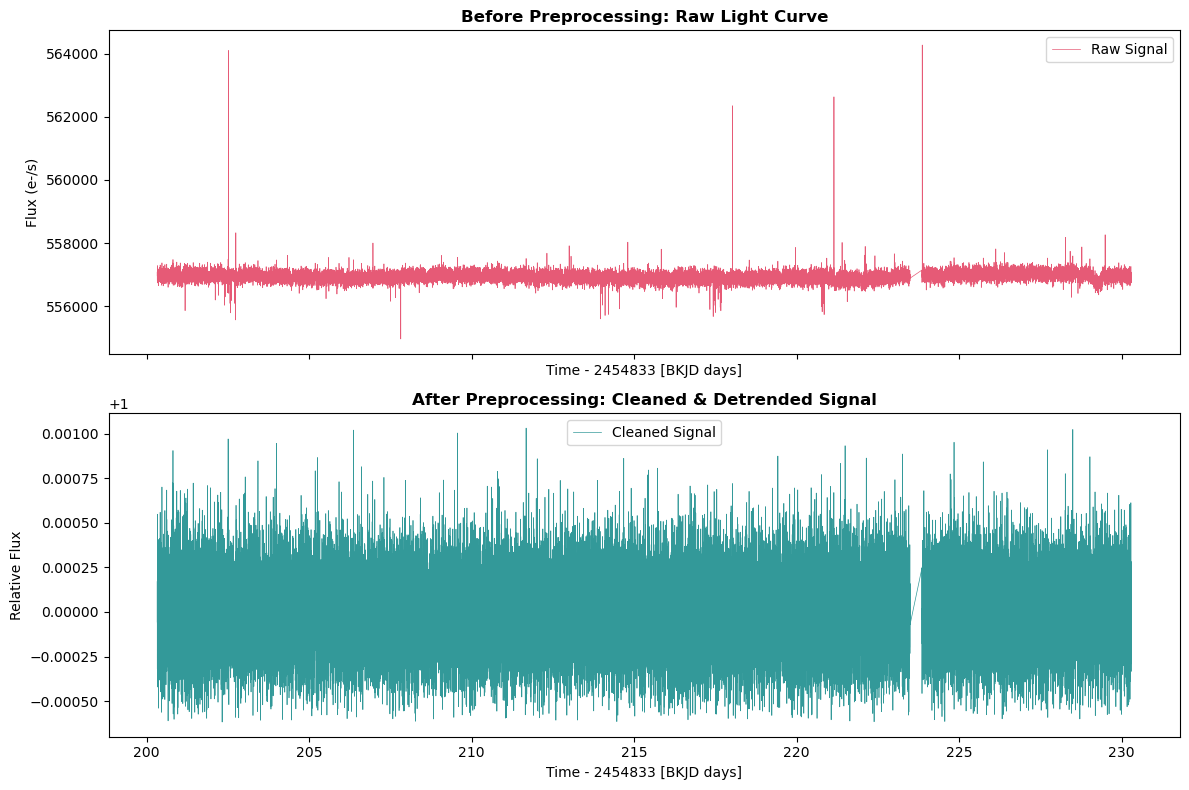

Figure saved successfully to: ../figures/02_raw_vs_cleaned_light_curve.png


In [18]:
import os
import matplotlib.pyplot as plt

# Ensure destination directory exists (parent directory 'figures' folder)
os.makedirs("../figures", exist_ok=True)

# Create two-panel plot comparing Raw vs. Cleaned signals
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: Raw Signal
ax1 = lc_raw.plot(ax=axes[0], color='crimson', alpha=0.7, label='Raw Signal')
axes[0].set_title("Before Preprocessing: Raw Light Curve", fontweight='bold')
axes[0].set_ylabel("Flux (e-/s)")
axes[0].legend()

# Panel 2: Cleaned Signal
ax2 = lc_cleaned.plot(ax=axes[1], color='teal', alpha=0.8, label='Cleaned Signal')
axes[1].set_title("After Preprocessing: Cleaned & Detrended Signal", fontweight='bold')
axes[1].set_ylabel("Relative Flux")
axes[1].legend()

plt.tight_layout()

# Save figure to destination folder
output_path = "../figures/02_raw_vs_cleaned_light_curve.png"
plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(f"Figure saved successfully to: {output_path}")

## Preprocessing Summary & Output

- **Input:** `lc_raw` (Raw electron/sec flux with trends, missing data, and noise).
- **Output:** `lc_cleaned` (Normalized, detrended relative flux centered at 1.0 with noise/outliers removed).
- **Saved Figure:** `02_raw_vs_cleaned_light_curve.png`

---

## Next Step
👉 **STEP 3 — Period Search (Box Least Squares / BLS)**
Search `lc_cleaned` for periodic transit dips to identify exoplanet candidates and measure their orbital period.